# Crafter DR / MAC changed focal：实时对数图

每次重新运行下面的单元格，都会从 `results/` 重新读取最新 CSV。横轴是 WM 更新次数；MAC 的前 10 轮 warmup 不计入横轴。纵轴为对数刻度，越低越好。依次显示综合、layout 和 inventory changed focal。

每组读取 seed 0–4。在每个 WM 更新位置，粗线为已有 seed 的均值（尚未跑到该位置的 seed 不参与平均）；至少有两个 seed 时，阴影为已有 seed 的最小值到最大值，不是置信区间。DR 同一 seed 若有新旧两份 CSV，读取已完成更新次数更多的一份，不把两次运行混合。


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "test/crafter_dr_mac_50/conf/config_mac_crafter_dr_mac_50.yaml").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open Jupyter from the project root or test/crafter_dr_mac_50.")
RESULTS = ROOT / "test/crafter_dr_mac_50/results"
METRICS = [
    ("target_val_changed_focal_loss", "Combined changed focal loss"),
    ("target_val_layout_changed_focal_loss", "Layout changed focal loss"),
    ("target_val_inventory_changed_focal_loss", "Inventory changed focal loss"),
]
RUNS = {
    "MAC": {
        seed: (RESULTS / f"mac/mac_balanced_ewc20_epoch10_seed{seed}/mac_crafter_lp_layout_stage_novelty_results.csv",)
        for seed in range(5)
    },
    "DR": {
        seed: (
            RESULTS / f"dr/dr_ewc20_epoch10_seed{seed}/dr_crafter_results.csv",
            RESULTS / f"dr/seed{seed}/dr_crafter_results.csv",
        )
        for seed in range(5)
    },
}

# Re-read every file whenever this cell runs. Only completed CSV rows are plotted.
frames = {}
for method, paths in RUNS.items():
    frames[method] = {}
    for seed, candidates in paths.items():
        available = [(path, pd.read_csv(path)) for path in candidates if path.is_file()]
        if not available:
            continue
        path, frame = max(available, key=lambda item: item[1]["Iter"].max() if not item[1].empty else -1)
        required = {"Iter", *(name for name, _ in METRICS)}
        missing = required - set(frame.columns)
        if missing:
            raise ValueError(f"{path} is missing CSV columns: {sorted(missing)}")
        frame = frame.copy()
        frame["WM_update"] = frame["Iter"].astype(int) - (10 if method == "MAC" else 0)
        frame = frame.loc[frame["WM_update"] > 0]
        if frame.empty:
            continue  # MAC may still be in its ten warmup rounds.
        frame = frame.drop_duplicates("WM_update", keep="last").set_index("WM_update").sort_index()
        frames[method][seed] = frame
    status = ", ".join(f"seed {seed}: {int(frame.index.max())} updates" for seed, frame in frames[method].items())
    print(f"{method}: {status or 'no CSV yet'}")

colors = {"MAC": "#204d95", "DR": "#27935c"}
fig, axes = plt.subplots(len(METRICS), 1, figsize=(9, 13), sharex=True, constrained_layout=True)
for ax, (column, title) in zip(axes, METRICS):
    for method in ("MAC", "DR"):
        seeds = frames[method]
        if not seeds:
            continue
        color = colors[method]
        for seed, frame in seeds.items():
            values = frame[column].to_numpy(dtype=float)
            if not np.isfinite(values).all() or np.any(values <= 0):
                raise ValueError(f"{method} seed {seed} {column} has a nonpositive or nonfinite value; log scale needs positive losses")
        values = pd.concat({seed: frame[column] for seed, frame in seeds.items()}, axis=1).sort_index()
        updates = values.index.to_numpy()
        counts = values.count(axis=1).to_numpy()
        if np.any(counts >= 2):
            ax.fill_between(updates, values.min(axis=1).to_numpy(), values.max(axis=1).to_numpy(),
                            where=counts >= 2, color=color, alpha=0.22, label=f"{method} seed range")
        ax.plot(updates, values.mean(axis=1).to_numpy(), color=color, linewidth=2.3,
                marker="o", markersize=3, label=f"{method} mean (1–5 available seeds)")
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_ylabel("Loss (log scale; lower is better)")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
axes[-1].set_xlabel("WM update (MAC warmup excluded)")
fig.suptitle("Crafter DR vs MAC | uniform targets 1–4 × 500", fontsize=12)
output = RESULTS / "changed_focal_log_combined_live_wide.png"
fig.savefig(output, dpi=180)
plt.show()
print(f"Saved: {output}")


## 5 次更新移动平均

先运行上面的原始曲线单元格以重新读取最新 CSV，再运行下面的单元格。先分别对每个 seed 做最近 5 次 WM 更新的移动平均，再计算跨 seed 均值和最小值–最大值阴影；前 4 个点使用当时已有的数据。阴影仍不是置信区间。


In [ ]:
SMOOTH_WINDOW = 5
if "frames" not in globals():
    raise RuntimeError("Run the original plot cell first to load the latest CSV files.")

fig, axes = plt.subplots(len(METRICS), 1, figsize=(9, 13), sharex=True, constrained_layout=True)
for ax, (column, title) in zip(axes, METRICS):
    for method in ("MAC", "DR"):
        seeds = frames[method]
        if not seeds:
            continue
        color = colors[method]
        smoothed = pd.concat(
            {seed: frame[column].rolling(SMOOTH_WINDOW, min_periods=1).mean()
             for seed, frame in seeds.items()},
            axis=1,
        ).sort_index()
        updates = smoothed.index.to_numpy()
        counts = smoothed.count(axis=1).to_numpy()
        if np.any(counts >= 2):
            ax.fill_between(
                updates, smoothed.min(axis=1).to_numpy(), smoothed.max(axis=1).to_numpy(),
                where=counts >= 2, color=color, alpha=0.22, label=f"{method} seed range",
            )
        ax.plot(
            updates, smoothed.mean(axis=1).to_numpy(), color=color, linewidth=2.3,
            marker="o", markersize=3, label=f"{method} smoothed mean",
        )
    ax.set_yscale("log")
    ax.set_title(title)
    ax.set_ylabel("Loss (log scale; lower is better)")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
axes[-1].set_xlabel("WM update (MAC warmup excluded)")
fig.suptitle(
    f"Crafter DR vs MAC | uniform targets 1–4 × 500 | trailing {SMOOTH_WINDOW}-update mean",
    fontsize=12,
)
output_smooth = RESULTS / f"changed_focal_log_combined_smooth{SMOOTH_WINDOW}_live_wide.png"
fig.savefig(output_smooth, dpi=180)
plt.show()
print(f"Saved: {output_smooth}")


## 全量与少量目标验证：DR vs MAC

上图是训练时对目标 1–4（每个目标 500 个样本）的少量验证。下面两张图分别显示 20 个目标的全量验证和目标 1–4 的少量验证，指标都是综合 changed focal loss。每张图的两条线分别是 DR 和 MAC 在相同 WM 更新次数下的 seed 均值；阴影为均值 ± 1 个 seed 间标准差（`ddof=0`），仅在至少两个 seed 有数据时显示。每次运行都会重新读取 CSV。同一 seed 有新旧两份少量验证 CSV 时，选更新次数更多的一份，不混合两次运行。当前全量验证 DR 有 seed 0–4，MAC 只有 seed 0–1，图例会显示实际读取的 seed 数。


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "test/crafter_dr_mac_50/conf/config_mac_crafter_dr_mac_50.yaml").is_file()),
    None,
)
if ROOT is None:
    raise FileNotFoundError("Open Jupyter from the project root or test/crafter_dr_mac_50.")
RESULTS = ROOT / "test/crafter_dr_mac_50/results"
LOSS = "target_val_changed_focal_loss"
METHODS = ("DR", "MAC")
COLORS = {"DR": "#27935c", "MAC": "#204d95"}
curves = {"Full validation: 20 targets × 500": {}, "Small validation: targets 1–4 × 500": {}}

for method in METHODS:
    full_path = RESULTS / method.lower() / "full20_changed_focal.csv"
    full = pd.read_csv(full_path)
    required = {"Seed", "WM_Update", LOSS}
    if required - set(full.columns):
        raise ValueError(f"{full_path} is missing columns: {sorted(required - set(full.columns))}")
    full = full.loc[full["Seed"].isin(range(5))].drop_duplicates(["Seed", "WM_Update"], keep="last")
    curves["Full validation: 20 targets × 500"][method] = full.pivot(
        index="WM_Update", columns="Seed", values=LOSS,
    ).sort_index()

    small_seeds = {}
    for seed in range(5):
        if method == "DR":
            candidates = (
                RESULTS / f"dr/dr_ewc20_epoch10_seed{seed}/dr_crafter_results.csv",
                RESULTS / f"dr/seed{seed}/dr_crafter_results.csv",
            )
        else:
            candidates = (
                RESULTS / f"mac/mac_balanced_ewc20_epoch10_seed{seed}/mac_crafter_lp_layout_stage_novelty_results.csv",
            )
        available = [(path, pd.read_csv(path)) for path in candidates if path.is_file()]
        if not available:
            continue
        path, frame = max(available, key=lambda item: item[1]["Iter"].max() if not item[1].empty else -1)
        required = {"Iter", LOSS}
        if required - set(frame.columns):
            raise ValueError(f"{path} is missing columns: {sorted(required - set(frame.columns))}")
        updates = frame["Iter"].astype(int) - (10 if method == "MAC" else 0)
        series = pd.Series(frame[LOSS].to_numpy(dtype=float), index=updates.to_numpy())
        series = series.loc[series.index > 0]
        if not series.empty:
            small_seeds[seed] = series.loc[~series.index.duplicated(keep="last")]
    if small_seeds:
        curves["Small validation: targets 1–4 × 500"][method] = pd.concat(small_seeds, axis=1).sort_index()

fig, axes = plt.subplots(2, 1, figsize=(9, 10), sharex=True, constrained_layout=True)
for ax, (title, methods) in zip(axes, curves.items()):
    for method in METHODS:
        wide = methods.get(method)
        if wide is None or wide.empty:
            continue
        data = wide.to_numpy(dtype=float)
        present = ~np.isnan(data)
        if not np.isfinite(data[present]).all() or (data[present] <= 0).any():
            raise ValueError(f"{method} {title} contains a nonpositive or nonfinite loss")
        count = wide.count(axis=1).to_numpy()
        mean = wide.mean(axis=1).to_numpy()
        std = wide.std(axis=1, ddof=0).to_numpy()
        updates = wide.index.to_numpy()
        color = COLORS[method]
        ax.plot(updates, mean, color=color, linewidth=2.3,
                label=f"{method} mean ({len(wide.columns)} seeds)")
        ax.fill_between(updates, mean - std, mean + std,
                        where=(count >= 2) & (mean - std > 0),
                        color=color, alpha=0.22, label=f"{method} ±1 std")
        print(f"{title} | {method}: {len(wide.columns)} seeds, through update {int(wide.index.max())}")
    ax.set_title(title)
    ax.set_ylabel("Changed focal loss (log scale)")
    ax.set_yscale("log")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
axes[-1].set_xlabel("WM update (MAC warmup excluded)")
output = RESULTS / "full_vs_small_changed_focal_mean_std.png"
fig.savefig(output, dpi=180)
plt.show()
print(f"Saved: {output}")


## 全量验证：5 次更新移动平均

先运行上面的“全量与少量目标验证”单元格以重新读取 CSV。对每个 seed 的 20 目标 changed focal loss 分别计算最近 5 次 WM 更新的移动平均（前 4 个点使用已有更新），再逐次计算跨 seed 均值和 ±1 标准差阴影（`ddof=0`）。DR 和 MAC 各一条线；原始结果保留在上一张图。


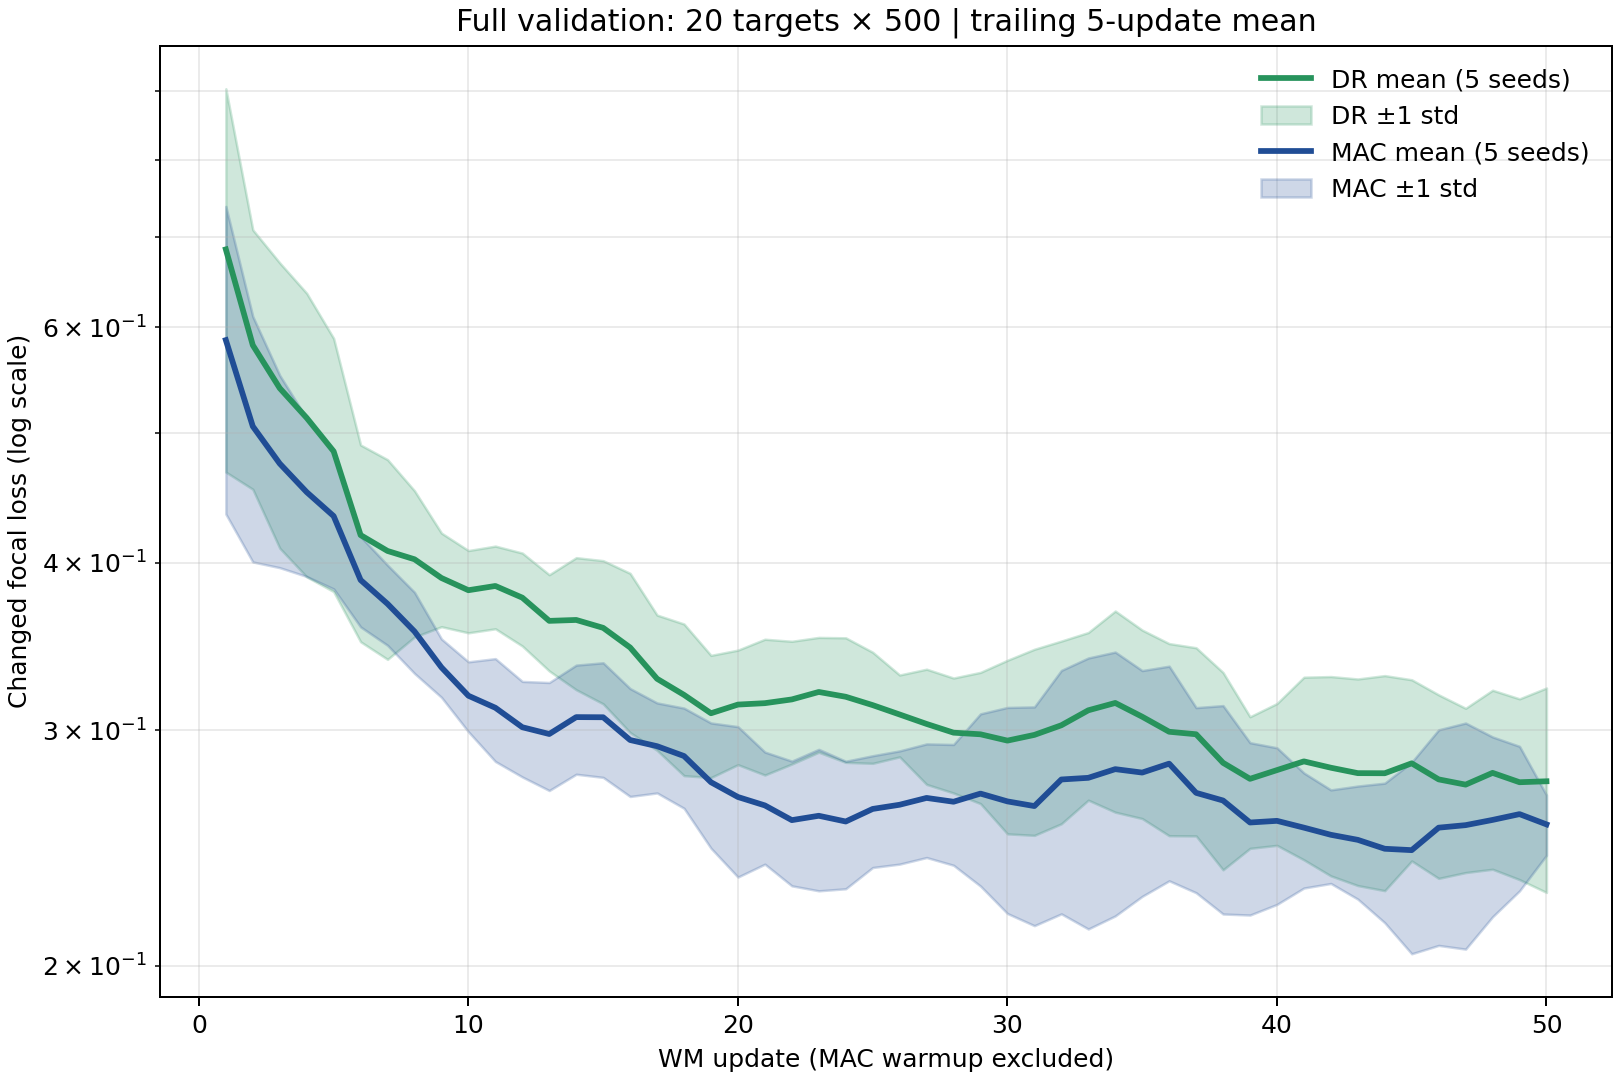

In [1]:
FULL_SMOOTH_WINDOW = 5
if "curves" not in globals():
    raise RuntimeError("Run the full-vs-small validation cell first to load the latest CSV files.")

full_curves = curves["Full validation: 20 targets × 500"]
fig, ax = plt.subplots(figsize=(9, 6), constrained_layout=True)
for method in METHODS:
    wide = full_curves.get(method)
    if wide is None or wide.empty:
        continue
    smoothed = wide.rolling(FULL_SMOOTH_WINDOW, min_periods=1).mean()
    count = smoothed.count(axis=1).to_numpy()
    mean = smoothed.mean(axis=1).to_numpy()
    std = smoothed.std(axis=1, ddof=0).to_numpy()
    updates = smoothed.index.to_numpy()
    color = COLORS[method]
    ax.plot(updates, mean, color=color, linewidth=2.3,
            label=f"{method} mean ({len(smoothed.columns)} seeds)")
    ax.fill_between(updates, mean - std, mean + std,
                    where=(count >= 2) & (mean - std > 0),
                    color=color, alpha=0.22, label=f"{method} ±1 std")
ax.set_yscale("log")
ax.set_title(f"Full validation: 20 targets × 500 | trailing {FULL_SMOOTH_WINDOW}-update mean")
ax.set_xlabel("WM update (MAC warmup excluded)")
ax.set_ylabel("Changed focal loss (log scale)")
ax.grid(alpha=0.25, which="both")
ax.legend(frameon=False)
output_smooth = RESULTS / "full20_changed_focal_smoothed_mean_std.png"
fig.savefig(output_smooth, dpi=180)
plt.show()
print(f"Saved: {output_smooth}")


## 20 目标综合 loss：五 seed 均值 ± 标准误

下面这张图使用与上面的全量标准差图相同的 20 个目标、每目标 500 样本和最近 5 次 WM 更新移动平均。粗线是五个 seed 的均值，阴影是均值 ±1 标准误（SEM，样本标准差 / √5），淡线保留每个 seed 的轨迹。SEM 表示均值估计的波动，不表示单个 seed 的波动；重新运行单元格会重新读取全量验证 CSV。


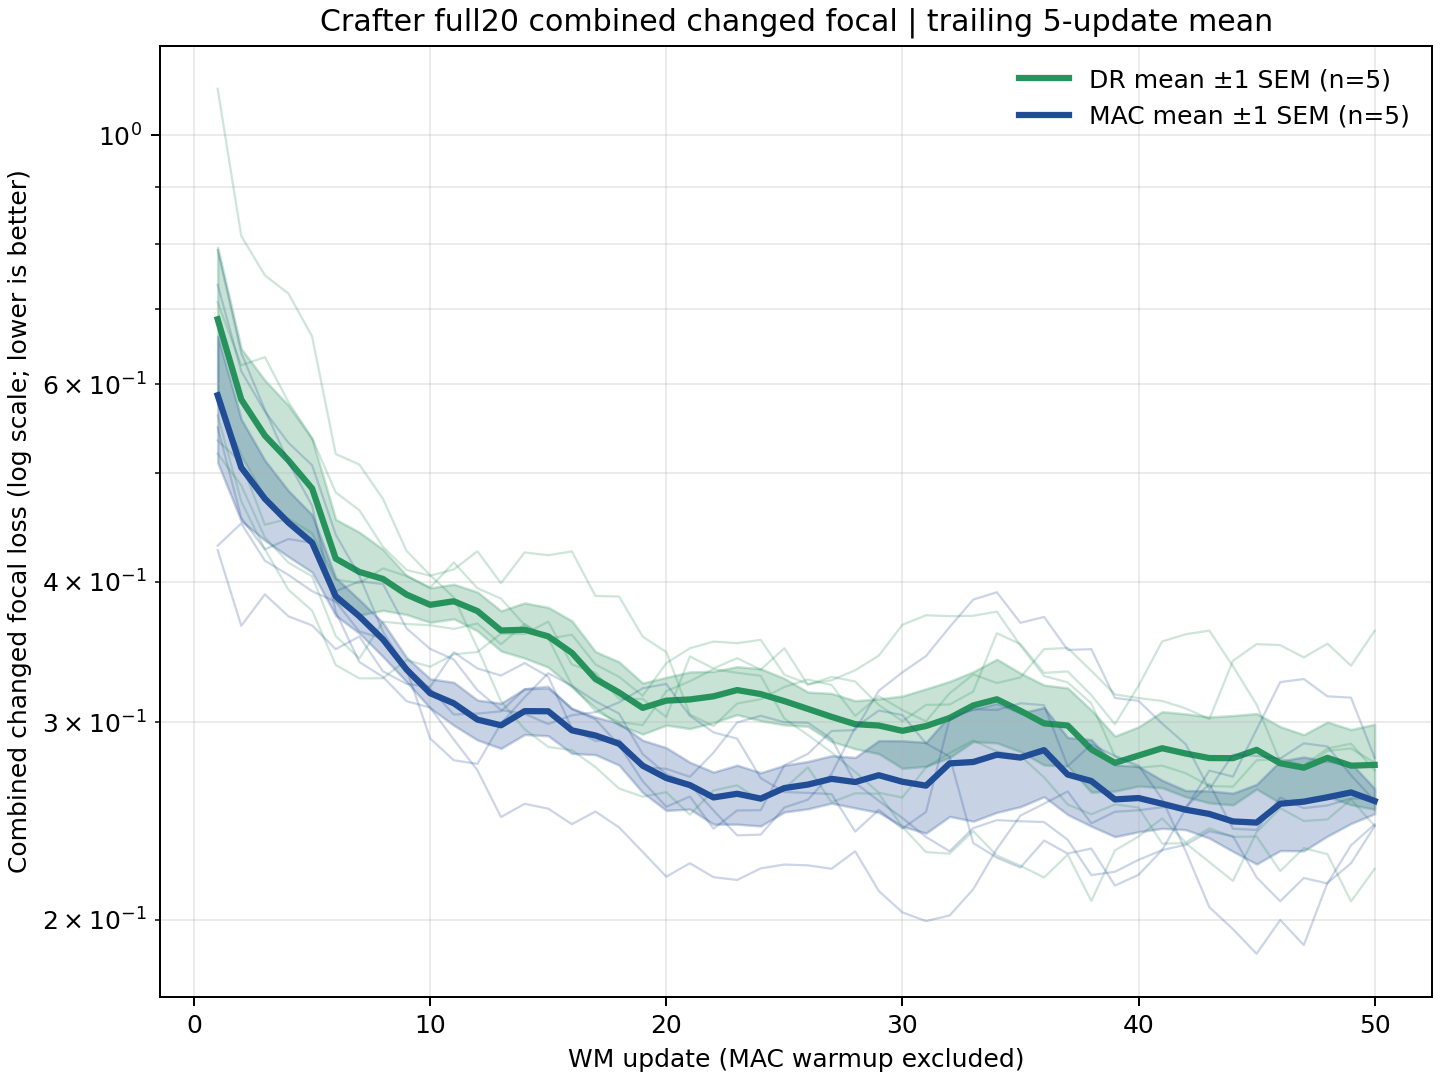

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEM_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "test/crafter_dr_mac_50/conf/config_mac_crafter_dr_mac_50.yaml").is_file()),
    None,
)
if SEM_ROOT is None:
    raise FileNotFoundError("Open Jupyter from the project root or test/crafter_dr_mac_50.")
SEM_RESULTS = SEM_ROOT / "test/crafter_dr_mac_50/results"
SEM_METRIC = "target_val_changed_focal_loss"
SEM_WINDOW = 5
SEM_COLORS = {"DR": "#27935c", "MAC": "#204d95"}

fig, ax = plt.subplots(figsize=(8, 6), constrained_layout=True)
for method, color in SEM_COLORS.items():
    path = SEM_RESULTS / method.lower() / "full20_changed_focal.csv"
    frame = pd.read_csv(path)
    required = {"Seed", "WM_Update", SEM_METRIC}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    frame = frame.loc[frame["Seed"].isin(range(5))]
    wide = frame.drop_duplicates(["Seed", "WM_Update"], keep="last").pivot(
        index="WM_Update", columns="Seed", values=SEM_METRIC
    ).sort_index()
    if set(wide.columns) != set(range(5)) or wide.isna().any().any():
        raise ValueError(f"{path} needs complete seed 0–4 full20 validation data")
    if not np.isfinite(wide.to_numpy()).all() or (wide.to_numpy() <= 0).any():
        raise ValueError(f"{path} contains a nonpositive or nonfinite loss")
    smooth = wide.rolling(SEM_WINDOW, min_periods=1).mean()
    for seed in range(5):
        ax.plot(smooth.index, smooth[seed], color=color, linewidth=0.9, alpha=0.23)
    mean = smooth.mean(axis=1)
    sem = smooth.std(axis=1, ddof=1) / np.sqrt(5)
    ax.fill_between(smooth.index.to_numpy(), (mean - sem).to_numpy(),
                    (mean + sem).to_numpy(), color=color, alpha=0.25)
    ax.plot(smooth.index, mean.to_numpy(), color=color, linewidth=2.5,
            label=f"{method} mean ±1 SEM (n=5)")
    print(f"{method}: 5 seeds, through WM {int(smooth.index.max())}")
ax.set_yscale("log")
ax.set_title("Crafter full20 combined changed focal | trailing 5-update mean")
ax.set_xlabel("WM update (MAC warmup excluded)")
ax.set_ylabel("Combined changed focal loss (log scale; lower is better)")
ax.grid(alpha=0.25, which="both")
ax.legend(frameon=False)
output = SEM_RESULTS / "full20_changed_focal_smoothed_mean_sem.png"
fig.savefig(output, dpi=180)
plt.show()
print(f"Saved: {output}")


## Quick MAC：综合 changed focal loss（seed 0/1）

重新运行下面的单元格会读取最新 CSV，比较 DR、旧 MAC 0.3、新 MAC 0.5 在目标 1–4 上的综合 changed focal loss。每种颜色的细线分别是 seed 0/1 的 5 次更新移动平均；粗线是两个 seed 都完成该 WM 更新时的均值，阴影是两个 seed 间 ±1 标准差。MAC 0.5 的两 seed 均值只画到较慢 seed 已完成的位置，后续只有 seed 0 的细线。MAC 的 10 次 warmup 不计入横轴；这里不是 20 目标全量验证。


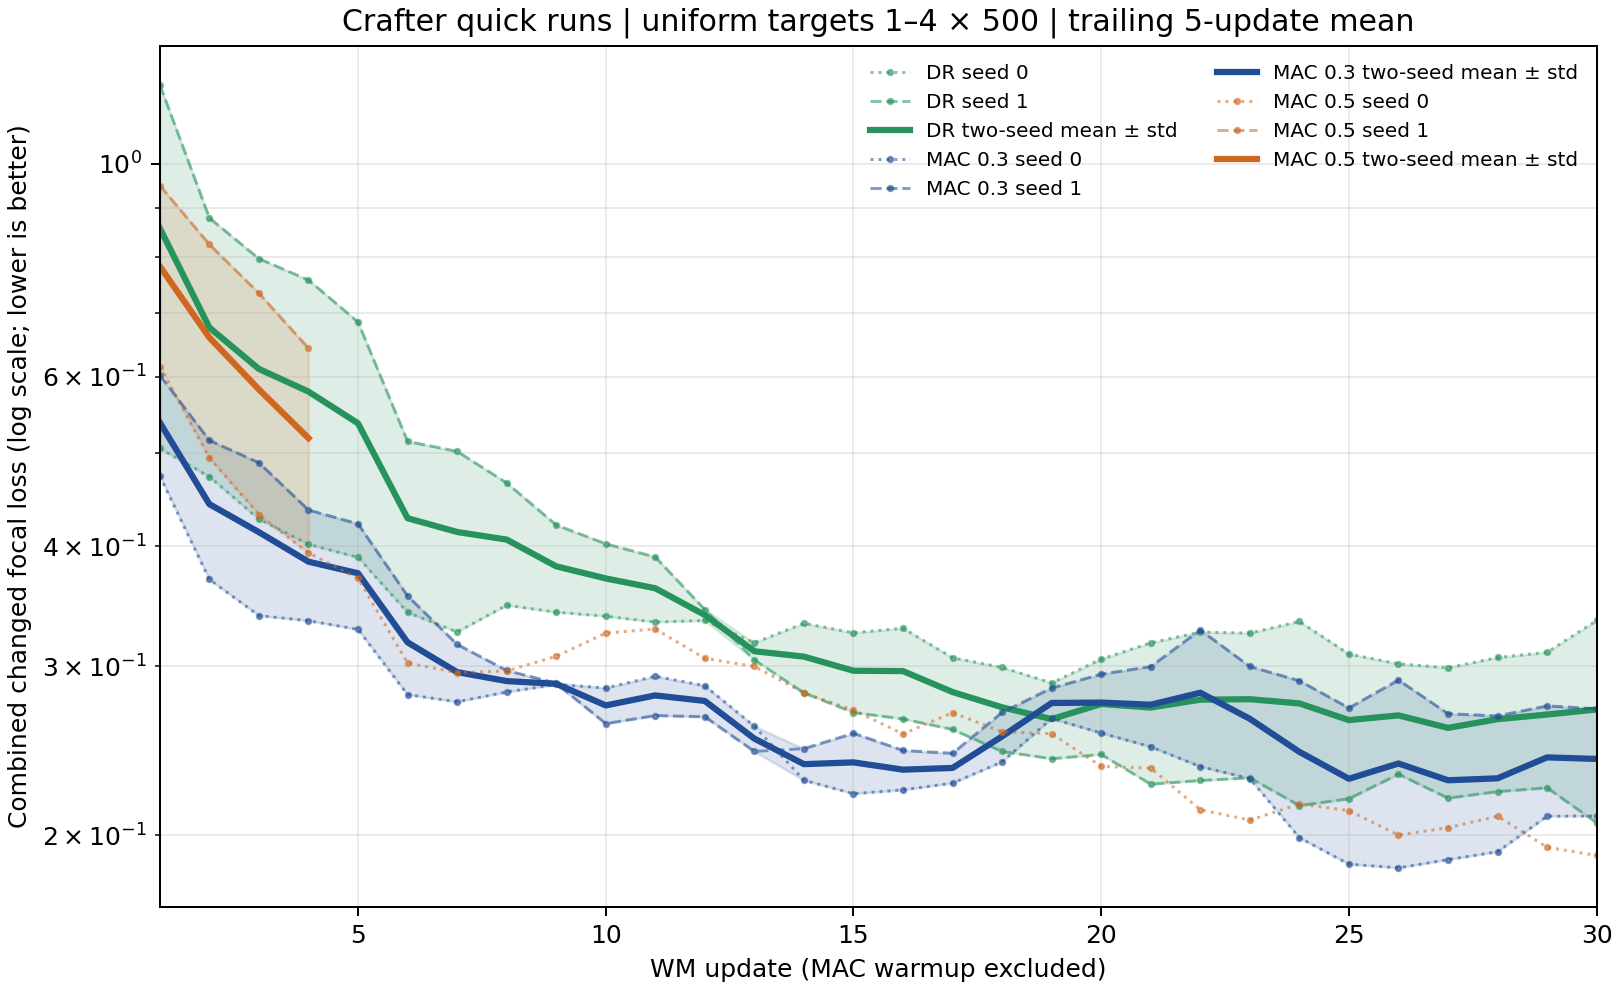

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

QUICK_COMBINED_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "test/crafter_dr_mac_50/conf/config_mac_crafter_dr_mac_50.yaml").is_file()),
    None,
)
if QUICK_COMBINED_ROOT is None:
    raise FileNotFoundError("Open Jupyter from the project root or test/crafter_dr_mac_50.")
QUICK_COMBINED_RESULTS = QUICK_COMBINED_ROOT / "test/crafter_dr_mac_50/results"
QUICK_COMBINED_METRIC = "target_val_changed_focal_loss"
QUICK_COMBINED_COLORS = {"DR": "#27935c", "MAC 0.3": "#204d95", "MAC 0.5": "#cf6720"}
QUICK_COMBINED_WINDOW = 5

fig, ax = plt.subplots(figsize=(9, 5.5), constrained_layout=True)
for method, color in QUICK_COMBINED_COLORS.items():
    seed_series = {}
    for seed in (0, 1):
        if method == "DR":
            path = QUICK_COMBINED_RESULTS / f"dr/seed{seed}/dr_crafter_results.csv"
        else:
            run = (
                f"mac_balanced_ewc20_epoch10_gen1_10plus30_edit05_local_seed{seed}"
                if method == "MAC 0.5" else
                ("mac_balanced_ewc20_epoch10_gen1_10plus30_local_seed0" if seed == 0
                 else "mac_balanced_ewc20_epoch10_gen1_10plus30_rerun_local_seed1")
            )
            path = QUICK_COMBINED_RESULTS / f"mac/{run}/mac_crafter_lp_layout_stage_novelty_results.csv"
        if not path.is_file():
            print(f"{method} seed {seed}: no CSV yet")
            continue
        frame = pd.read_csv(path)
        required = {"Iter", QUICK_COMBINED_METRIC}
        missing = required - set(frame.columns)
        if missing:
            raise ValueError(f"{path} is missing columns: {sorted(missing)}")
        frame = frame.copy()
        frame["WM_update"] = frame["Iter"].astype(int) - (0 if method == "DR" else 10)
        frame = frame.loc[frame["WM_update"] > 0]
        series = frame.drop_duplicates("WM_update", keep="last").set_index("WM_update")[QUICK_COMBINED_METRIC].astype(float).sort_index().dropna()
        if series.empty:
            print(f"{method} seed {seed}: warmup; no WM update yet")
            continue
        if not np.isfinite(series.to_numpy()).all() or (series <= 0).any():
            raise ValueError(f"{path} contains a nonpositive or nonfinite combined focal loss")
        series = series.loc[series.index <= 30].rolling(QUICK_COMBINED_WINDOW, min_periods=1).mean()
        seed_series[seed] = series
        ax.plot(series.index, series.to_numpy(), color=color, linestyle=":" if seed == 0 else "--",
                linewidth=1.2, alpha=0.55, marker="o", markersize=2,
                label=f"{method} seed {seed}")
        print(f"{method} seed {seed}: through WM {int(series.index.max())}")
    if len(seed_series) == 2:
        paired = pd.concat(seed_series, axis=1).dropna().sort_index()
        if not paired.empty:
            mean = paired.mean(axis=1)
            std = paired.std(axis=1, ddof=0)
            ax.fill_between(paired.index.to_numpy(), (mean - std).to_numpy(), (mean + std).to_numpy(),
                            color=color, alpha=0.15)
            ax.plot(paired.index, mean.to_numpy(), color=color, linewidth=2.5,
                    label=f"{method} two-seed mean ± std")
            print(f"{method}: two-seed mean through WM {int(paired.index.max())}")

ax.set_yscale("log")
ax.set_xlim(1, 30)
ax.set_xlabel("WM update (MAC warmup excluded)")
ax.set_ylabel("Combined changed focal loss (log scale; lower is better)")
ax.set_title("Crafter quick runs | uniform targets 1–4 × 500 | trailing 5-update mean")
ax.grid(alpha=0.25, which="both")
ax.legend(frameon=False, fontsize=8, ncol=2)
output = QUICK_COMBINED_RESULTS / "mac_edit05_vs_dr_combined_two_seeds_live.png"
fig.savefig(output, dpi=180)
plt.show()
print(f"Saved: {output}")


## DR 与 Quick MAC：layout LP 截断 ±3、±5（已有 WM 数据）

重新运行下面的单元格，读取 DR seed 0/1，以及 MAC seed 0/1 的原设置（±3）和新设置（±5）10+30 quick 实验。DR 取前 30 次 WM 更新；MAC 从第 11 轮起排除 10 轮 warmup。每个 seed 只要有目标 1–4 的综合 changed focal loss 就画出当前轨迹；尚未开始或仍在 warmup 的 seed 暂不加入。每个 seed 先做 5 次 WM 更新移动平均，再在每个 WM 更新位置对已有 seed 求均值；有两个 seed 时，阴影是 seed 间 ±1 标准差。图例列出已有数据的 seed；两组 seed 数量或更新长度不同时，曲线只用于观察早期走势。横轴不含 MAC 前 10 轮 warmup。这里不是 20 目标全量验证。


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

CLIP_COMPARE_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "test/crafter_dr_mac_50/conf/config_mac_crafter_dr_mac_50.yaml").is_file()),
    None,
)
if CLIP_COMPARE_ROOT is None:
    raise FileNotFoundError("Open Jupyter from the project root or test/crafter_dr_mac_50.")
CLIP_COMPARE_RESULTS = CLIP_COMPARE_ROOT / "test/crafter_dr_mac_50/results"
CLIP_COMPARE_METRIC = "target_val_changed_focal_loss"
CLIP_COMPARE_WINDOW = 5
CLIP_COMPARE_RUNS = {
    "DR": {seed: f"seed{seed}" for seed in (0, 1)},
    "layout LP clip ±3": {
        0: "mac_balanced_ewc20_epoch10_gen1_10plus30_local_seed0",
        1: "mac_balanced_ewc20_epoch10_gen1_10plus30_rerun_local_seed1",
    },
    "layout LP clip ±5": {
        seed: f"mac_balanced_ewc20_epoch10_gen1_10plus30_layoutclip5_local_seed{seed}"
        for seed in (0, 1)
    },
}
CLIP_COMPARE_COLORS = {"DR": "#27935c", "layout LP clip ±3": "#204d95", "layout LP clip ±5": "#cf6720"}


def available_clip_series(method, run):
    if method == "DR":
        path = CLIP_COMPARE_RESULTS / "dr" / run / "dr_crafter_results.csv"
        warmup = 0
    else:
        path = (CLIP_COMPARE_RESULTS / "mac" / run /
                "mac_crafter_lp_layout_stage_novelty_results.csv")
        warmup = 10
    if not path.is_file():
        return None, "no CSV"
    frame = pd.read_csv(path)
    required = {"Iter", CLIP_COMPARE_METRIC}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    frame = frame.drop_duplicates("Iter", keep="last").set_index("Iter").sort_index()
    series = pd.to_numeric(
        frame.loc[(frame.index > warmup) & (frame.index <= warmup + 30), CLIP_COMPARE_METRIC],
        errors="coerce",
    ).dropna()
    if series.empty:
        return None, "warmup; no WM validation yet"
    if not np.isfinite(series.to_numpy()).all() or (series <= 0).any():
        raise ValueError(f"{path} contains a nonpositive or nonfinite combined focal loss")
    series.index = pd.Index(series.index - warmup, name="WM update")
    return series.rolling(CLIP_COMPARE_WINDOW, min_periods=1).mean(), f"through WM {int(series.index.max())}"


clip_series = {method: {} for method in CLIP_COMPARE_RUNS}
for seed in (0, 1):
    runs = {method: available_clip_series(method, names[seed])
            for method, names in CLIP_COMPARE_RUNS.items()}
    print(f"seed {seed}: " + "; ".join(f"{method}: {status}" for method, (_, status) in runs.items()))
    for method, (series, _) in runs.items():
        if series is not None:
            clip_series[method][seed] = series

if not any(clip_series.values()):
    print("No WM validation yet; rerun this cell when a seed has data after warmup.")
else:
    fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
    for method, color in CLIP_COMPARE_COLORS.items():
        available_seeds = sorted(clip_series[method])
        if not available_seeds:
            print(f"{method}: no WM validation yet")
            continue
        wide = pd.DataFrame(clip_series[method])[available_seeds]
        for seed in available_seeds:
            ax.plot(wide.index, wide[seed], color=color, alpha=0.3, linewidth=1,
                    linestyle=":" if seed == 0 else "--")
        mean = wide.mean(axis=1)
        if len(available_seeds) > 1:
            std = wide.std(axis=1, ddof=0)
            has_two_seeds = wide.count(axis=1) >= 2
            ax.fill_between(wide.index.to_numpy(), (mean - std).to_numpy(),
                            (mean + std).to_numpy(), where=has_two_seeds.to_numpy(),
                            color=color, alpha=0.18)
        ax.plot(wide.index, mean.to_numpy(), color=color, linewidth=2.5,
                label=f"{method} (seeds {available_seeds})")
        print(f"{method}: latest WM {int(mean.index.max())} combined loss = {mean.iloc[-1]:.6f}")
    ax.set_yscale("log")
    ax.set_xlim(1, 30)
    ax.set_xlabel("WM update (MAC warmup excluded)")
    ax.set_ylabel("Combined changed focal loss (log scale; lower is better)")
    ax.set_title("Crafter DR / MAC clip ±3 / ±5 | targets 1–4 × 500")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
    output = CLIP_COMPARE_RESULTS / "dr_vs_mac_layoutclip3_vs_5_combined_live.png"
    fig.savefig(output, dpi=180)
    plt.show()
    print(f"Saved: {output}")


## DR 与 MAC：LP probe 1000 对 2000（截断 ±3）

重新运行下面的单元格，读取 DR seed 0/1、原 MAC（LP probe 总预算 1000）seed 0/1，以及新 MAC（预算 2000）已有的 seed 0/1 数据。两组 MAC 的 layout LP 截断均为默认 ±3；其余训练配置与原 10+30 quick 实验一致。DR 取前 30 次 WM 更新，MAC 不计前 10 轮 warmup。每个 seed 的验证综合 changed focal loss 先做最近 5 次 WM 更新移动平均，再按每轮已有 seed 求均值；两个 seed 都有数据的位置才画 ±1 seed 间标准差阴影。图例标出参与的 seed，每条均值线的最新验证点用实心圆标出；新实验只有一个 seed 或尚未完成时，曲线仅作早期观察，不能据此确定最终优劣。验证使用目标 1–4、每目标 500 样本，并非 20 目标全量验证。


In [ ]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROBE_COMPARE_ROOT = next(
    (path for path in (Path.cwd(), *Path.cwd().parents)
     if (path / "test/crafter_dr_mac_50/conf/config_mac_crafter_dr_mac_50.yaml").is_file()),
    None,
)
if PROBE_COMPARE_ROOT is None:
    raise FileNotFoundError("Open Jupyter from the project root or test/crafter_dr_mac_50.")
PROBE_COMPARE_RESULTS = PROBE_COMPARE_ROOT / "test/crafter_dr_mac_50/results"
PROBE_COMPARE_METRIC = "target_val_changed_focal_loss"
PROBE_COMPARE_WINDOW = 5
PROBE_COMPARE_RUNS = {
    "DR": {seed: f"seed{seed}" for seed in (0, 1)},
    "MAC LP probe 1000": {
        0: "mac_balanced_ewc20_epoch10_gen1_10plus30_local_seed0",
        1: "mac_balanced_ewc20_epoch10_gen1_10plus30_rerun_local_seed1",
    },
    "MAC LP probe 2000": {
        seed: f"mac_balanced_ewc20_epoch10_gen1_10plus30_lp_probe2000_local_seed{seed}"
        for seed in (0, 1)
    },
}
PROBE_COMPARE_COLORS = {"DR": "#27935c", "MAC LP probe 1000": "#204d95", "MAC LP probe 2000": "#cf6720"}


def available_probe_series(method, run):
    if method == "DR":
        path = PROBE_COMPARE_RESULTS / "dr" / run / "dr_crafter_results.csv"
        warmup = 0
    else:
        path = (PROBE_COMPARE_RESULTS / "mac" / run /
                "mac_crafter_lp_layout_stage_novelty_results.csv")
        warmup = 10
    if not path.is_file():
        return None, "no CSV"
    frame = pd.read_csv(path)
    required = {"Iter", PROBE_COMPARE_METRIC}
    missing = required - set(frame.columns)
    if missing:
        raise ValueError(f"{path} is missing columns: {sorted(missing)}")
    frame = frame.drop_duplicates("Iter", keep="last").set_index("Iter").sort_index()
    series = pd.to_numeric(
        frame.loc[(frame.index > warmup) & (frame.index <= warmup + 30), PROBE_COMPARE_METRIC],
        errors="coerce",
    ).dropna()
    if series.empty:
        return None, "warmup; no WM validation yet"
    if not np.isfinite(series.to_numpy()).all() or (series <= 0).any():
        raise ValueError(f"{path} contains a nonpositive or nonfinite combined focal loss")
    series.index = pd.Index(series.index - warmup, name="WM update")
    return series.rolling(PROBE_COMPARE_WINDOW, min_periods=1).mean(), f"through WM {int(series.index.max())}"


clip_series = {method: {} for method in PROBE_COMPARE_RUNS}
for seed in (0, 1):
    runs = {method: available_probe_series(method, names[seed])
            for method, names in PROBE_COMPARE_RUNS.items()}
    print(f"seed {seed}: " + "; ".join(f"{method}: {status}" for method, (_, status) in runs.items()))
    for method, (series, _) in runs.items():
        if series is not None:
            clip_series[method][seed] = series

if not any(clip_series.values()):
    print("No WM validation yet; rerun this cell when a seed has data after warmup.")
else:
    fig, ax = plt.subplots(figsize=(8, 5.5), constrained_layout=True)
    for method, color in PROBE_COMPARE_COLORS.items():
        available_seeds = sorted(clip_series[method])
        if not available_seeds:
            print(f"{method}: no WM validation yet")
            continue
        wide = pd.DataFrame(clip_series[method])[available_seeds]
        for seed in available_seeds:
            ax.plot(wide.index, wide[seed], color=color, alpha=0.3, linewidth=1,
                    linestyle=":" if seed == 0 else "--")
        mean = wide.mean(axis=1)
        if len(available_seeds) > 1:
            std = wide.std(axis=1, ddof=0)
            has_two_seeds = wide.count(axis=1) >= 2
            ax.fill_between(wide.index.to_numpy(), (mean - std).to_numpy(),
                            (mean + std).to_numpy(), where=has_two_seeds.to_numpy(),
                            color=color, alpha=0.18)
        ax.plot(wide.index, mean.to_numpy(), color=color, linewidth=2.5,
                label=f"{method} (seeds {available_seeds})")
        ax.scatter(mean.index[-1], mean.iloc[-1], color=color, s=32, zorder=5)
        print(f"{method}: latest WM {int(mean.index.max())} combined loss = {mean.iloc[-1]:.6f}")
    ax.set_yscale("log")
    ax.set_xlim(1, 30)
    ax.set_xlabel("WM update (MAC warmup excluded)")
    ax.set_ylabel("Combined changed focal loss (log scale; lower is better)")
    ax.set_title("Crafter DR / MAC LP probe 1000 / 2000 | targets 1–4 × 500")
    ax.grid(alpha=0.25, which="both")
    ax.legend(frameon=False)
    output = PROBE_COMPARE_RESULTS / "dr_mac_lp_probe1000_vs_2000_combined_live.png"
    fig.savefig(output, dpi=180)
    plt.show()
    print(f"Saved: {output}")
